# PO-LR

This notebook demonstrates how NASH is much more effective than vanilla Data Shapley in the **PO-LR** setting.

In [10]:
import numpy as np
import torch

In [11]:
from main.utils.datasets import load_dataset

X_train, y_train, X_val, y_val = load_dataset('pol')

In [12]:
from main.utils.random import set_random_seed

SEED = 122
set_random_seed(SEED)

In [13]:
if torch.cuda.is_available():
    device = torch.device('cuda', index=0)
else:
    device = torch.device('cpu')

device

device(type='cuda', index=0)

### Data Shapley

The following code uses Monte-Carlo approximation of Data Shapley to get each datum's Data Shapley score and per-validation-datum Data Shapley scores simultaneously.

In [14]:
from main.shapley.mc import monte_carlo_shapley
from main.utility_functions.logr import get_logr_utility

shapleys, ps_shapleys = monte_carlo_shapley(get_logr_utility, X_train, y_train, X_val, y_val, n_perms=500)
shapleys.shape, ps_shapleys.shape

Permutations: 100%|██████████| 500/500 [00:11<00:00, 41.69it/s]


((200,), (200, 2000))

In [15]:
shapley_order = np.argsort(shapleys)[::-1]
shapley_order

array([ 41, 106,  62, 110,  54, 176, 103, 109,  52,  98, 151,  18,  71,
       126, 121,  84, 122, 160,  51,  75,  34,  28, 190,  85,  20, 172,
         3, 129, 137, 182,  61,  86,  57,  10, 150,  80,  95,   8, 164,
        59, 180, 159,  53,  13,  30,  99, 196, 186,  76, 188,  46, 140,
       146, 130, 116,  48,  36, 153,  64, 115,   2,  14,  39,  45,   6,
       169,  74,  66, 158, 171, 178,  43, 193, 101,  69, 174, 194, 185,
       179, 139, 143, 144, 141, 120,  32, 192,  87, 113, 111, 127,  40,
       165, 195,  26,  56, 152,  91, 148,  90,  92, 163, 133,  72, 136,
       154, 173,   5, 187,  47, 123,  58,  79, 149, 147,  33,  31,  82,
       191, 198,  19, 118, 197, 105,  37,  77,  65,  17, 181,  11, 119,
       128, 107,  50,  73,  78, 100,  93,  42,  24,   7,  15, 117, 114,
       177,  27,  29,  25,  60, 162,  89, 161, 132,  63, 170, 167,  67,
       183,  96,  68,   9, 199,  88,  70,  21, 189,   4, 125, 138,  35,
       108, 155, 166,  97,  22, 145, 184,  94,   0, 134,  55, 16

### NASH

In [19]:
from main.selection.nash import nash_selection

def ftau(x, uplambda=2):
    return 1 - torch.exp(-uplambda * x)

ps_shapleys_tensor = torch.from_numpy(ps_shapleys)
nash_order = nash_selection(ps_shapleys_tensor, 200, lambda x: ftau(x), device=device, seed=SEED)
nash_order

100%|██████████| 200/200 [00:00<00:00, 3139.13it/s]


array([ 41, 109, 151,  54, 126, 176,  84,  52, 116,  98,  75,   3,  28,
        85,  86,  51,  10, 164,  69,   8, 137, 146,  95, 172,  59,  40,
       153,  34,  99, 140, 196, 101, 182,  74,  80, 129, 193,  48, 113,
        46,  31,  36,  30, 171, 186,  53,  42, 103,  76, 147,  64,  18,
        27,  57,  45,  71,  67, 180, 194, 115, 159,  66,  87, 166, 130,
       117,  43, 143,  20, 158, 198,  91, 106,  90,  68, 191, 120, 133,
       163,  72, 127,  14, 136,   5, 170,  39, 173, 197, 148, 138, 178,
       141, 144, 195, 169,  25, 149, 192, 167, 121, 107,  73,   4,  24,
       150, 104, 123,  19,   2,  56,  33,  88, 190,  94,  79, 139, 160,
        92,   0,  13,  50, 179, 154,  65,  47,  26,  63,  78, 187, 162,
       188, 134,  82,  62,   6, 183,  22, 161, 145,  58, 174, 105, 119,
       142,   7, 118, 114,  89,  32, 181, 124, 128, 185,  44,  96, 110,
        15,   9,  60,  77,  93,  21, 131,  55,  61,  23, 165,  35, 108,
       112, 152,  97, 100,  29,  70, 122, 175,  11, 132,  17, 11

### Results

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from main.utility_functions.logr import get_logr_utility

shapley_performances = []
nash_performances = []
n_selecteds = list(range(10, 201, 2))

for n_selected in n_selecteds:
    shapley_performances.append(100*get_logr_utility(X_train[shapley_order[:n_selected]], y_train[shapley_order[:n_selected]], X_val, y_val, per_sample=False))
    nash_performances.append(100*get_logr_utility(X_train[nash_order[:n_selected]], y_train[nash_order[:n_selected]], X_val, y_val, per_sample=False))

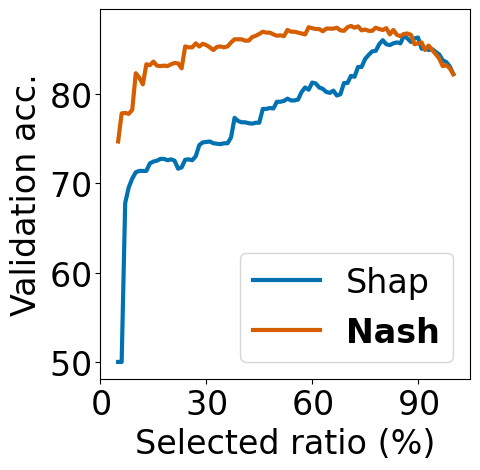

In [33]:
import os

fig, ax = plt.subplots()
ax.set_box_aspect(1) 

n_selecteds = np.array(n_selecteds)
colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#56B4E9", "#F0E442", "#CC79A7"]
ax.plot(n_selecteds / len(X_train) * 100, shapley_performances, linewidth=3, label=f"Shap", color=colors[0])
ax.plot(n_selecteds / len(X_train) * 100, nash_performances, linewidth=3, label=f"Nash", color=colors[3])

FONT_SIZE = 24
ax.tick_params(axis='both', labelsize=FONT_SIZE)
ax.xaxis.set_major_formatter('${x:.0f}$')
ax.yaxis.set_major_formatter('${x:.0f}$')
ax.set_xlabel(r"Selected ratio (%)", fontsize=FONT_SIZE)
ax.set_xticks([0, 30, 60, 90])
ax.set_ylabel(r"Validation acc.", fontsize=FONT_SIZE)
leg = ax.legend(fontsize=FONT_SIZE)
for text in leg.get_texts():
    if text.get_text() == "Nash":
        text.set_fontweight('bold')
plt.show()